In [3]:
import pandas as pd

df = pd.read_csv("data/berlin-listings.csv.gz", compression="gzip")

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,https://www.airbnb.com/rooms/3176,20250923202926,2025-09-24,city scrape,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,The neighbourhood is famous for its variety of...,https://a0.muscache.com/pictures/hosting/Hosti...,3718,...,4.70,4.92,4.61,First name and Last name: Nicolas Krotz <br/> ...,f,1,1,0,0,0.76
1,9991,https://www.airbnb.com/rooms/9991,20250923202926,2025-09-24,city scrape,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,Prenzlauer Berg is an amazing neighbourhood wh...,https://a0.muscache.com/pictures/42799131/59c8...,33852,...,5.00,4.86,4.86,03/Z/RA/003410-18,f,1,1,0,0,0.06
2,14325,https://www.airbnb.com/rooms/14325,20250923202926,2025-09-24,city scrape,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,https://a0.muscache.com/pictures/508703/24988a...,55531,...,4.85,4.60,4.45,NaN,f,4,4,0,0,0.14
3,17904,https://www.airbnb.com/rooms/17904,20250923202926,2025-09-24,city scrape,Beautiful Kreuzberg studio - 3 months minimum,"- apt is available starting October 1, 2025 (m...","The apartment is located in Kreuzberg, which i...",https://a0.muscache.com/pictures/d9a6f8be-54b9...,68997,...,4.92,4.88,4.65,NaN,f,1,1,0,0,1.57
4,20858,https://www.airbnb.com/rooms/20858,20250923202926,2025-09-24,city scrape,Designer Loft in Berlin Mitte,Bright and sunny condo with two balconies in a...,Fantastic vibe in the middle of the popular Ka...,https://a0.muscache.com/pictures/108232/205b19...,71331,...,4.54,4.91,4.39,03/Z/RA/009767-24,f,1,1,0,0,0.89


In [4]:
df["price"].head()

0    $105.00
1    $135.00
2     $75.00
3     $32.00
4    $202.00
Name: price, dtype: str

In [5]:
df["price"] = df["price"].replace("[\$,]", "", regex=True).astype(float)

df["price"].head()

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/var/folders/8_/pccl6c5d1xgf5d543nwyt5jm0000gn/T/ipykernel_39251/985560100.py:1: SyntaxWarning: invalid escape sequence '\$'
  df["price"] = df["price"].replace("[\$,]", "", regex=True).astype(float)


0    105.0
1    135.0
2     75.0
3     32.0
4    202.0
Name: price, dtype: float64

In [6]:
df["price"].describe()

count     9264.000000
mean       201.240393
std       1656.989769
min          5.000000
25%         70.000000
50%        104.000000
75%        160.000000
max      50000.000000
Name: price, dtype: float64

In [7]:
pd.options.display.float_format = "{:.2f}".format

In [8]:
df["price"].describe()

count    9264.00
mean      201.24
std      1656.99
min         5.00
25%        70.00
50%       104.00
75%       160.00
max     50000.00
Name: price, dtype: float64

In [9]:
df[df["price"] > 1000]["price"].sort_values(ascending=False).head(10)

10626   50000.00
10622   50000.00
10620   50000.00
10566   50000.00
10565   50000.00
10628   50000.00
10623   40000.00
10624   40000.00
10621   40000.00
10627   40000.00
Name: price, dtype: float64

In [10]:
df = df[df["price"] < 1000]

In [11]:
df["price"].describe()

count   9221.00
mean     129.44
std       95.00
min        5.00
25%       70.00
50%      104.00
75%      160.00
max      999.00
Name: price, dtype: float64

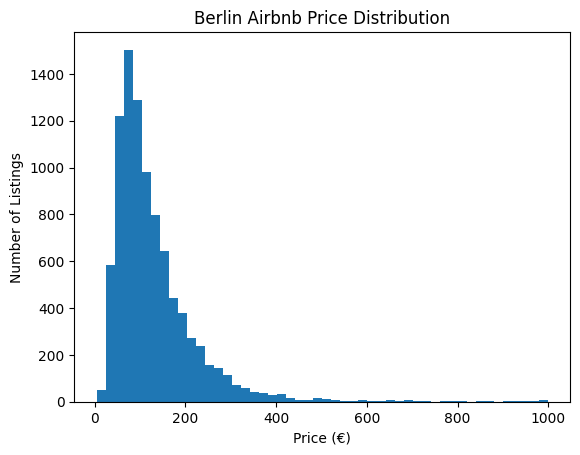

In [12]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=50)
plt.title("Berlin Airbnb Price Distribution")
plt.xlabel("Price (€)")
plt.ylabel("Number of Listings")

plt.show()

In [13]:
df.groupby("room_type")["price"].mean().sort_values(ascending=False)

room_type
Hotel room        210.79
Entire home/apt   144.02
Private room       85.94
Shared room        48.21
Name: price, dtype: float64

In [14]:
df["neighbourhood_cleansed"].nunique()

138

In [15]:
df.groupby("neighbourhood_cleansed")["price"].mean().sort_values(ascending=False).head(10)

neighbourhood_cleansed
West 5                    381.55
Haselhorst                216.17
Regierungsviertel         185.89
Brunnenstr. Nord          179.65
Prenzlauer Berg Südwest   175.64
Brunnenstr. Süd           174.47
Schmargendorf             170.56
Charlottenburg Nord       167.17
Alexanderplatz            164.76
Spandau Mitte             153.12
Name: price, dtype: float64

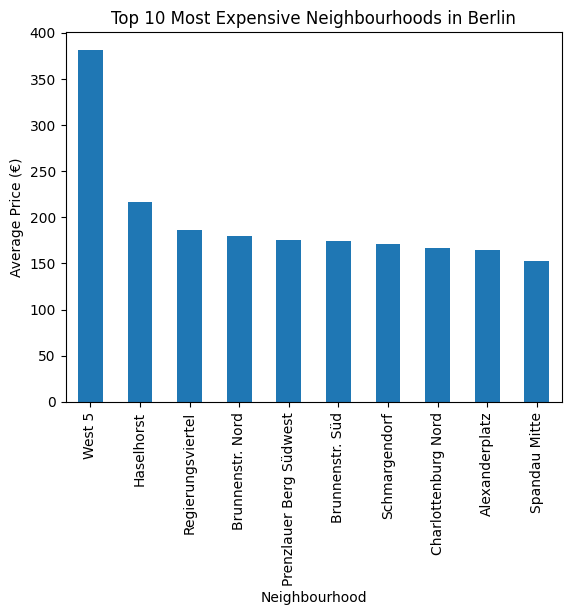

In [16]:
top_neighbourhoods = (
    df.groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_neighbourhoods.plot(kind="bar")

plt.title("Top 10 Most Expensive Neighbourhoods in Berlin")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price (€)")

plt.show()

In [17]:
df["neighbourhood_cleansed"].value_counts().head(10)

neighbourhood_cleansed
Alexanderplatz              710
Frankfurter Allee Süd FK    475
Tempelhofer Vorstadt        419
Brunnenstr. Süd             400
Prenzlauer Berg Südwest     290
südliche Luisenstadt        242
Schöneberg-Nord             212
Prenzlauer Berg Süd         197
Prenzlauer Berg Nordwest    193
Karl-Marx-Allee-Süd         183
Name: count, dtype: int64

In [18]:
df.groupby("neighbourhood_cleansed").agg(
    average_price=("price", "mean"),
    listing_count=("price", "count")
)

,average_price,listing_count
neighbourhood_cleansed,,
Adlershof,100.19,31
Albrechtstr.,115.49,55
Alexanderplatz,164.76,710
Allende-Viertel,38.67,3
Alt Treptow,114.20,50
...,...,...
Wilhelmstadt,130.12,17
Zehlendorf Nord,119.06,49
Zehlendorf Südwest,116.76,29


In [19]:
result = (
    df.groupby("neighbourhood_cleansed")
      .agg(avg_price=("price","mean"),
           listing_count=("price","count"))
)

result[result["listing_count"] > 50].sort_values("avg_price", ascending=False).head(10)

,avg_price,listing_count
neighbourhood_cleansed,,
Regierungsviertel,185.89,98
Brunnenstr. Nord,179.65,160
Prenzlauer Berg Südwest,175.64,290
Brunnenstr. Süd,174.47,400
Alexanderplatz,164.76,710
Tiergarten Süd,152.15,115
Kurfürstendamm,149.88,139
Neue Kantstraße,148.97,88
Südliche Friedrichstadt,144.60,180


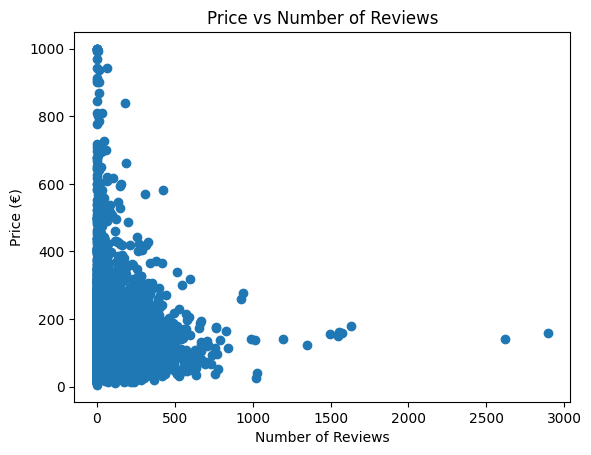

In [20]:
plt.scatter(df["number_of_reviews"], df["price"])

plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price (€)")

plt.show()

/var/folders/8_/pccl6c5d1xgf5d543nwyt5jm0000gn/T/ipykernel_39251/486316321.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=room_types)


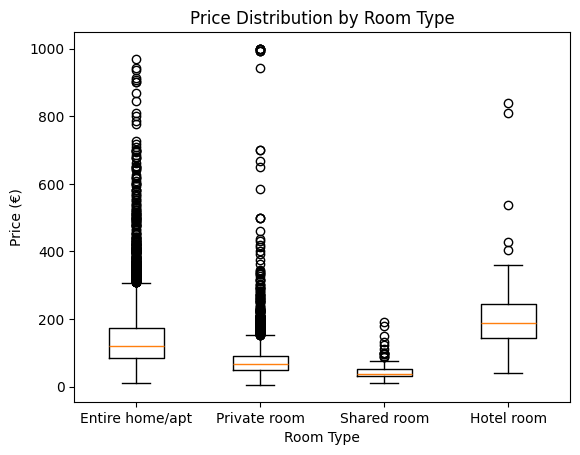

In [21]:
room_types = df["room_type"].unique()

data = [df[df["room_type"] == room]["price"] for room in room_types]

plt.boxplot(data, labels=room_types)

plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price (€)")

plt.show()

In [22]:
df.groupby(["neighbourhood_cleansed", "room_type"])["price"].mean().sort_values(ascending=False).head(10)

neighbourhood_cleansed   room_type      
Westend                  Hotel room        810.00
West 5                   Private room      453.62
Prenzlauer Berg Südwest  Hotel room        421.17
Charlottenburg Nord      Entire home/apt   269.33
Halensee                 Hotel room        260.25
Kurfürstendamm           Hotel room        236.25
Haselhorst               Entire home/apt   216.17
Düsseldorfer Straße      Hotel room        216.00
Friedenau                Hotel room        212.20
Spandau Mitte            Hotel room        210.00
Name: price, dtype: float64

In [23]:
pivot = df.pivot_table(
    index="neighbourhood_cleansed",
    columns="room_type",
    values="price",
    aggfunc="mean"
)

pivot.head(10)

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood_cleansed,,,,
Adlershof,104.77,NaN,94.50,45.00
Albrechtstr.,132.57,NaN,47.18,NaN
Alexanderplatz,165.76,204.82,187.80,49.49
Allende-Viertel,50.00,NaN,33.00,NaN
Alt Treptow,133.31,NaN,65.07,NaN
Alt-Hohenschönhausen Nord,178.50,NaN,50.00,NaN
Alt-Hohenschönhausen Süd,131.60,NaN,54.50,NaN
Alt-Lichtenberg,130.90,NaN,106.27,NaN
Altglienicke,85.84,NaN,49.50,NaN


In [24]:
df.isna().sum().sort_values(ascending=False)

calendar_updated          9221
host_neighbourhood        6026
neighbourhood             5073
neighborhood_overview     5073
host_about                4173
                          ... 
maximum_nights               0
minimum_nights_avg_ntm       0
maximum_nights_avg_ntm       0
availability_30              0
amenities                    0
Length: 79, dtype: int64

In [25]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [26]:
features = [
    "price",
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "instant_bookable",
    "host_is_superhost",
    "calculated_host_listings_count"
]

In [27]:
analysis_df = df[features]

analysis_df.head()

,price,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,beds,bathrooms,minimum_nights,availability_365,number_of_reviews,reviews_per_month,review_scores_rating,instant_bookable,host_is_superhost,calculated_host_listings_count
0,105.00,Prenzlauer Berg Südwest,Entire home/apt,Entire rental unit,2,1.00,2.00,1.00,63,140,150,0.76,4.63,f,f,1
1,135.00,Prenzlauer Berg Südwest,Entire home/apt,Entire rental unit,7,4.00,4.00,2.50,6,241,7,0.06,5.00,f,f,1
2,75.00,Prenzlauer Berg Nordwest,Entire home/apt,Entire rental unit,1,0.00,1.00,1.00,150,168,26,0.14,4.68,f,f,4
3,32.00,Reuterstraße,Entire home/apt,Entire rental unit,2,0.00,1.00,1.00,93,72,298,1.57,4.77,f,f,1
4,202.00,Prenzlauer Berg Südwest,Entire home/apt,Entire loft,4,2.00,2.00,1.00,3,253,140,0.89,4.48,f,f,1


In [28]:
analysis_df.select_dtypes(include="number").corr()

,price,accommodates,bedrooms,beds,bathrooms,minimum_nights,availability_365,number_of_reviews,reviews_per_month,review_scores_rating,calculated_host_listings_count
price,1.00,0.53,0.47,0.40,0.31,-0.20,0.07,-0.01,-0.01,0.04,0.01
accommodates,0.53,1.00,0.71,0.77,0.33,-0.16,0.06,0.08,0.07,-0.06,-0.04
bedrooms,0.47,0.71,1.00,0.65,0.41,-0.05,0.02,-0.01,-0.00,0.02,-0.04
beds,0.40,0.77,0.65,1.00,0.34,-0.14,0.05,0.07,0.03,-0.08,-0.06
bathrooms,0.31,0.33,0.41,0.34,1.00,-0.04,0.01,0.01,-0.01,0.03,-0.04
minimum_nights,-0.20,-0.16,-0.05,-0.14,-0.04,1.00,0.19,-0.23,-0.23,-0.02,0.24
availability_365,0.07,0.06,0.02,0.05,0.01,0.19,1.00,-0.01,0.09,-0.14,-0.02
number_of_reviews,-0.01,0.08,-0.01,0.07,0.01,-0.23,-0.01,1.00,0.65,0.04,-0.11
reviews_per_month,-0.01,0.07,-0.00,0.03,-0.01,-0.23,0.09,0.65,1.00,0.04,-0.04
review_scores_rating,0.04,-0.06,0.02,-0.08,0.03,-0.02,-0.14,0.04,0.04,1.00,-0.18


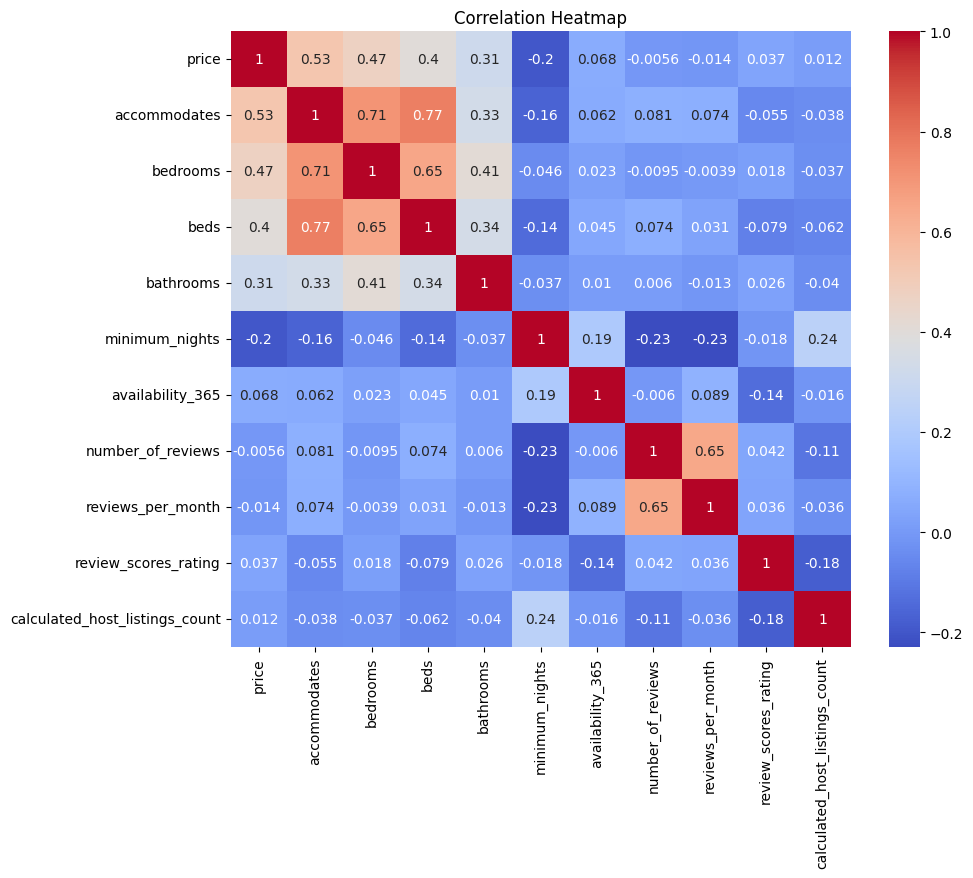

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    analysis_df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
df["property_type"].value_counts().head(10)

property_type
Entire rental unit                   5270
Private room in rental unit          1345
Entire condo                          494
Entire serviced apartment             419
Room in hotel                         233
Private room in condo                 199
Entire loft                           172
Private room in home                  172
Entire home                           136
Private room in bed and breakfast      63
Name: count, dtype: int64

In [31]:
top_property_types = df["property_type"].value_counts().head(6).index

top_property_types

Index(['Entire rental unit', 'Private room in rental unit', 'Entire condo',
       'Entire serviced apartment', 'Room in hotel', 'Private room in condo'],
      dtype='str', name='property_type')

In [32]:
df[df["property_type"].isin(top_property_types)]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,https://www.airbnb.com/rooms/3176,20250923202926,2025-09-24,city scrape,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,The neighbourhood is famous for its variety of...,https://a0.muscache.com/pictures/hosting/Hosti...,3718,...,4.70,4.92,4.61,First name and Last name: Nicolas Krotz <br/> ...,f,1,1,0,0,0.76
1,9991,https://www.airbnb.com/rooms/9991,20250923202926,2025-09-24,city scrape,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,Prenzlauer Berg is an amazing neighbourhood wh...,https://a0.muscache.com/pictures/42799131/59c8...,33852,...,5.00,4.86,4.86,03/Z/RA/003410-18,f,1,1,0,0,0.06
2,14325,https://www.airbnb.com/rooms/14325,20250923202926,2025-09-24,city scrape,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,https://a0.muscache.com/pictures/508703/24988a...,55531,...,4.85,4.60,4.45,NaN,f,4,4,0,0,0.14
3,17904,https://www.airbnb.com/rooms/17904,20250923202926,2025-09-24,city scrape,Beautiful Kreuzberg studio - 3 months minimum,"- apt is available starting October 1, 2025 (m...","The apartment is located in Kreuzberg, which i...",https://a0.muscache.com/pictures/d9a6f8be-54b9...,68997,...,4.92,4.88,4.65,NaN,f,1,1,0,0,1.57
6,22677,https://www.airbnb.com/rooms/22677,20250923202926,2025-09-24,city scrape,"""Prenzel Garten"" mit Terrasse",Relax in our little garden after exploring Ber...,The apartment is located in a very lively dist...,https://a0.muscache.com/pictures/miso/Hosting-...,87357,...,4.89,4.93,4.69,01/Z/NA/004976-16,f,1,1,0,0,3.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14269,1515762441083891582,https://www.airbnb.com/rooms/1515762441083891582,20250923202926,2025-09-24,city scrape,Cozy 2-Bedroom Apartment in Pankow,This stunning furnished two bedroom apartment ...,Pankow offers a peaceful retreat while still b...,https://a0.muscache.com/pictures/prohost-api/H...,595670462,...,NaN,NaN,NaN,NaN,f,107,107,0,0,NaN
14270,1515762449478095365,https://www.airbnb.com/rooms/1515762449478095365,20250923202926,2025-09-24,city scrape,Beautiful 1-Bedroom Apartment in Neukölln,This stunning furnished one bedroom apartment ...,"Welcome to Neukölln, a vibrant mosaic of cultu...",https://a0.muscache.com/pictures/prohost-api/H...,595670462,...,NaN,NaN,NaN,NaN,f,107,107,0,0,NaN
14271,1515796546337797524,https://www.airbnb.com/rooms/1515796546337797524,20250923202926,2025-09-24,city scrape,Tasteful Studio in Kreuzberg,This stunning furnished studio apartment featu...,Kreuzberg is one of Berlin’s most dynamic and ...,https://a0.muscache.com/pictures/prohost-api/H...,595670462,...,NaN,NaN,NaN,NaN,f,107,107,0,0,NaN
14272,1515901877338207449,https://www.airbnb.com/rooms/1515901877338207449,20250923202926,2025-09-24,city scrape,Large bright room with balcony in historic Rix...,This unique place has a style all its own.,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,21803389,...,NaN,NaN,NaN,08/Z/AZ/213486-24,f,2,1,1,0,NaN


In [33]:
filtered_df = df[df["property_type"].isin(top_property_types)]

In [34]:
filtered_df["property_type"].value_counts()

property_type
Entire rental unit             5270
Private room in rental unit    1345
Entire condo                    494
Entire serviced apartment       419
Room in hotel                   233
Private room in condo           199
Name: count, dtype: int64

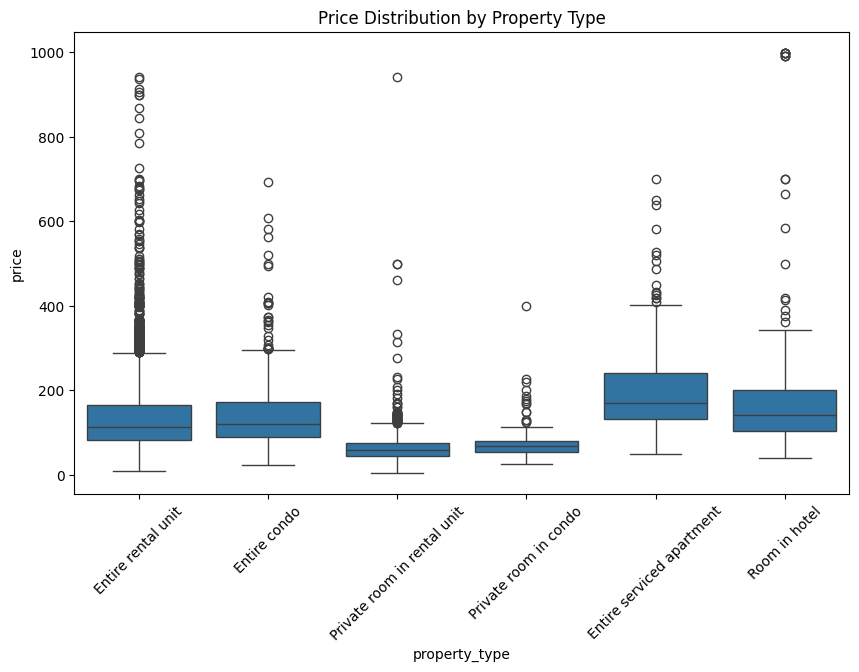

In [35]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="property_type",
    y="price",
    data=filtered_df
)

plt.title("Price Distribution by Property Type")

plt.xticks(rotation=45)

plt.show()

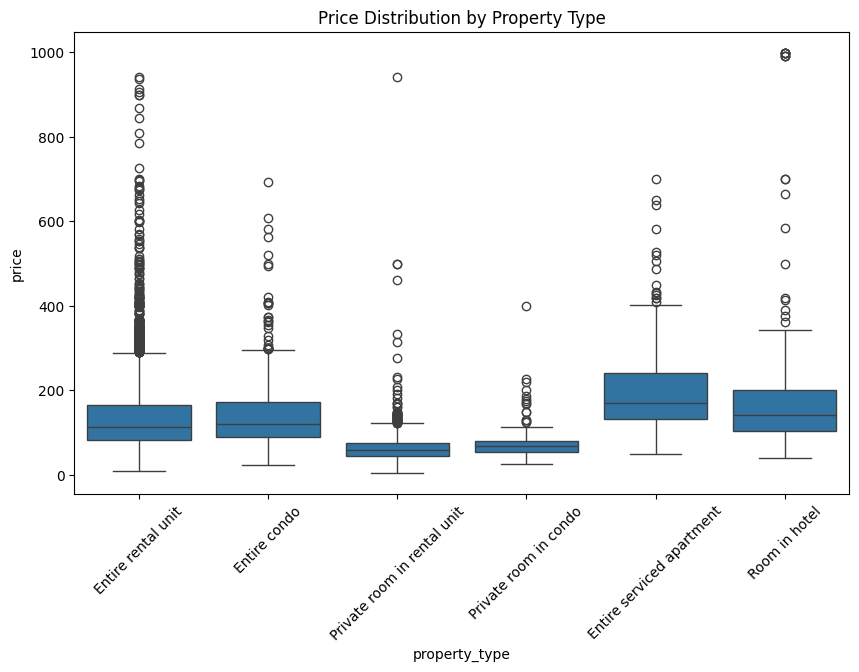

In [36]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="property_type",
    y="price",
    data=filtered_df
)

plt.title("Price Distribution by Property Type")

plt.xticks(rotation=45)

plt.show()

In [37]:
filtered_df_500 = filtered_df[filtered_df["price"] < 500]

filtered_df_500.shape

(7886, 79)

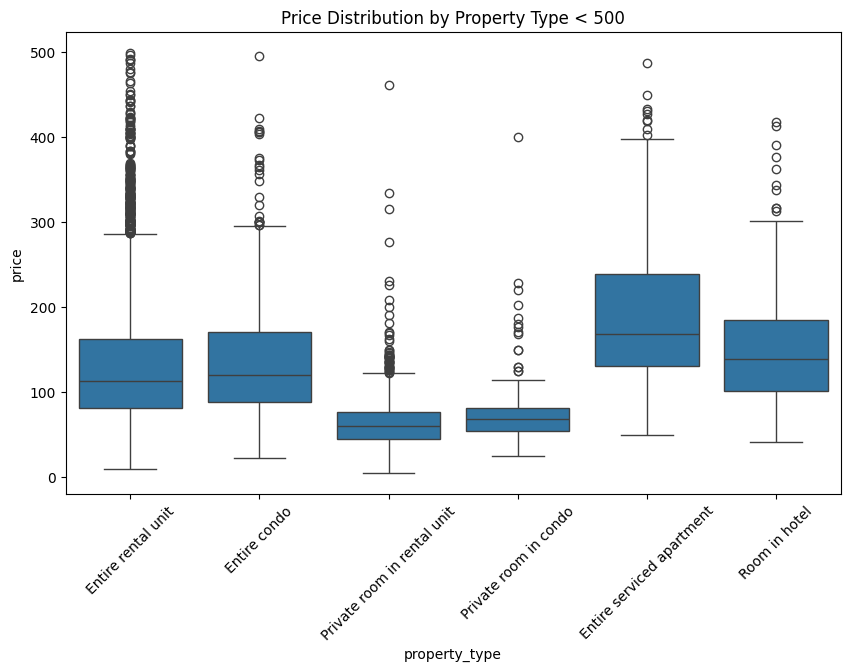

In [38]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="property_type",
    y="price",
    data=filtered_df_500
)

plt.title("Price Distribution by Property Type < 500")

plt.xticks(rotation=45)

plt.show()

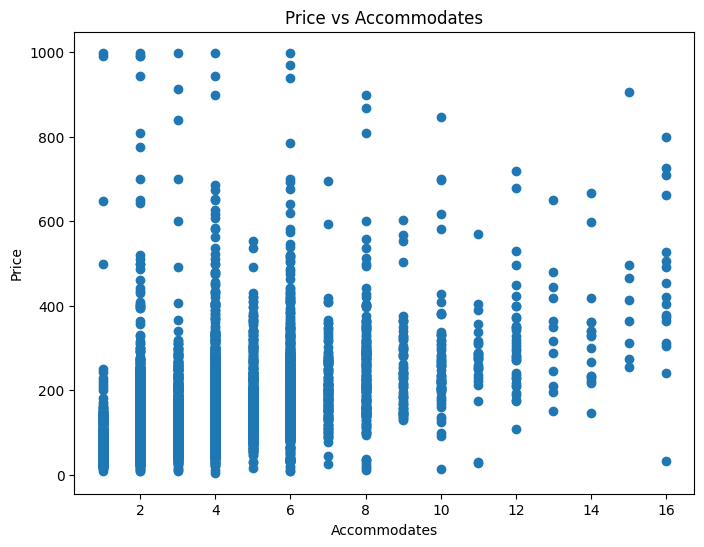

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    analysis_df["accommodates"],
    analysis_df["price"]
)

plt.xlabel("Accommodates")

plt.ylabel("Price")

plt.title("Price vs Accommodates")

plt.show()

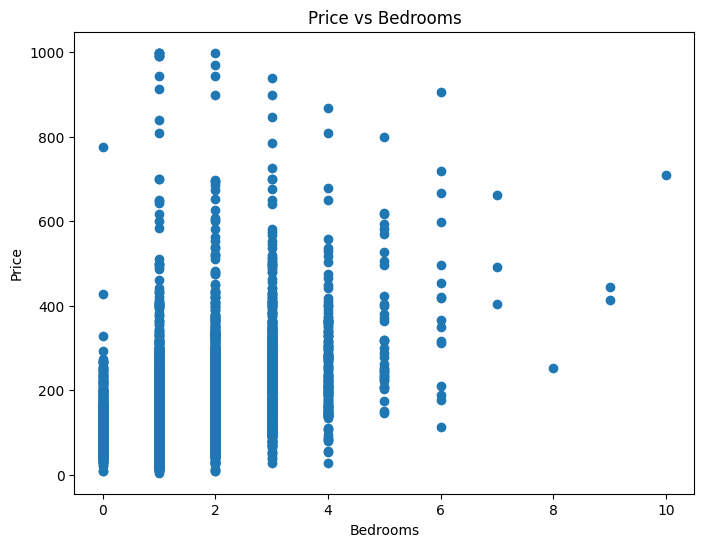

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    analysis_df["bedrooms"],
    analysis_df["price"]
)

plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Price vs Bedrooms")

plt.show()

In [41]:
analysis_df.isna().sum().sort_values(ascending=False)

reviews_per_month                 2048
review_scores_rating              2048
host_is_superhost                  140
bedrooms                            46
beds                                 9
bathrooms                            5
price                                0
neighbourhood_cleansed               0
room_type                            0
property_type                        0
accommodates                         0
minimum_nights                       0
availability_365                     0
number_of_reviews                    0
instant_bookable                     0
calculated_host_listings_count       0
dtype: int64

In [42]:
model_df = analysis_df[
[
"price",
"accommodates",
"bedrooms",
"beds",
"bathrooms",
"property_type",
"room_type",
"neighbourhood_cleansed",
"review_scores_rating"
]
]

In [43]:
model_df.head()

,price,accommodates,bedrooms,beds,bathrooms,property_type,room_type,neighbourhood_cleansed,review_scores_rating
0,105.00,2,1.00,2.00,1.00,Entire rental unit,Entire home/apt,Prenzlauer Berg Südwest,4.63
1,135.00,7,4.00,4.00,2.50,Entire rental unit,Entire home/apt,Prenzlauer Berg Südwest,5.00
2,75.00,1,0.00,1.00,1.00,Entire rental unit,Entire home/apt,Prenzlauer Berg Nordwest,4.68
3,32.00,2,0.00,1.00,1.00,Entire rental unit,Entire home/apt,Reuterstraße,4.77
4,202.00,4,2.00,2.00,1.00,Entire loft,Entire home/apt,Prenzlauer Berg Südwest,4.48


In [44]:
model_df.isna().sum()

price                        0
accommodates                 0
bedrooms                    46
beds                         9
bathrooms                    5
property_type                0
room_type                    0
neighbourhood_cleansed       0
review_scores_rating      2048
dtype: int64

In [45]:
model_df["bedrooms"] = model_df["bedrooms"].fillna(
    model_df["bedrooms"].median()
)

In [46]:
model_df["beds"] = model_df["beds"].fillna( model_df["beds"].median() )

In [47]:
model_df["bathrooms"] = model_df["bathrooms"].fillna( model_df["bathrooms"].median() )

In [48]:
model_df = model_df.drop(columns=["review_scores_rating"])

In [49]:
model_df.isna().sum()

price                     0
accommodates              0
bedrooms                  0
beds                      0
bathrooms                 0
property_type             0
room_type                 0
neighbourhood_cleansed    0
dtype: int64

In [50]:
encoded_df = pd.get_dummies(model_df)

In [51]:
encoded_df.shape

(9221, 210)

In [52]:
encoded_df.head()

,price,accommodates,bedrooms,beds,bathrooms,property_type_Boat,property_type_Camper/RV,property_type_Campsite,property_type_Casa particular,property_type_Castle,...,neighbourhood_cleansed_West 3,neighbourhood_cleansed_West 4,neighbourhood_cleansed_West 5,neighbourhood_cleansed_Westend,neighbourhood_cleansed_Wiesbadener Straße,neighbourhood_cleansed_Wilhelmstadt,neighbourhood_cleansed_Zehlendorf Nord,neighbourhood_cleansed_Zehlendorf Südwest,neighbourhood_cleansed_nördliche Luisenstadt,neighbourhood_cleansed_südliche Luisenstadt
0,105.00,2,1.00,2.00,1.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,135.00,7,4.00,4.00,2.50,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,75.00,1,0.00,1.00,1.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,32.00,2,0.00,1.00,1.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,202.00,4,2.00,2.00,1.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [53]:
X = encoded_df.drop(columns=["price"])

In [54]:
y = encoded_df["price"]

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
model = LinearRegression()

In [60]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
predictions = model.predict(X_test)

In [62]:
from sklearn.metrics import mean_absolute_error

In [63]:
mean_absolute_error(y_test, predictions)

43.23556696895632

In [64]:
y.mean()

np.float64(129.43910638759354)

In [65]:
from sklearn.metrics import r2_score

In [66]:
r2_score(y_test, predictions)

0.4101203386829504

In [67]:
from sklearn.ensemble import RandomForestRegressor

In [68]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [69]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [70]:
rf_predictions = rf_model.predict(X_test)

In [71]:
mean_absolute_error(y_test, rf_predictions)

40.7543416645511

In [72]:
r2_score(y_test, rf_predictions)

0.4255738173706647

In [73]:
importance = rf_model.feature_importances_

In [74]:
importance

array([1.59377543e-01, 1.90173268e-01, 9.17644997e-02, 1.39233316e-01,
       1.82757556e-03, 1.32732166e-04, 1.48853867e-05, 1.05080304e-05,
       7.12342315e-05, 3.01444759e-06, 4.76848579e-06, 2.83595498e-04,
       1.73110195e-05, 8.92330410e-06, 7.51257496e-03, 3.92560413e-05,
       2.66639667e-04, 4.59413986e-04, 1.83122073e-03, 7.41913937e-03,
       8.55799743e-04, 1.06777527e-02, 2.25220593e-02, 5.46198468e-04,
       7.79009324e-04, 6.81714836e-05, 8.37959038e-03, 1.22332526e-05,
       5.43754801e-06, 2.12131612e-04, 6.04137637e-04, 4.61899345e-05,
       6.25935064e-06, 2.65733664e-05, 1.85427668e-06, 3.71422480e-05,
       9.44701703e-05, 1.10987011e-03, 5.59851104e-06, 2.44146835e-05,
       1.04746526e-04, 2.80573971e-03, 1.47403889e-03, 3.45823565e-04,
       2.01857450e-04, 9.02392842e-06, 3.26316730e-02, 1.78587130e-03,
       5.60841428e-05, 1.83035000e-04, 1.11094569e-05, 3.96882374e-05,
       6.70467720e-03, 3.31464488e-05, 5.02398521e-03, 3.01058408e-04,
      

In [75]:
encoded_df.columns

Index(['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
       'property_type_Boat', 'property_type_Camper/RV',
       'property_type_Campsite', 'property_type_Casa particular',
       'property_type_Castle',
       ...
       'neighbourhood_cleansed_West 3', 'neighbourhood_cleansed_West 4',
       'neighbourhood_cleansed_West 5', 'neighbourhood_cleansed_Westend',
       'neighbourhood_cleansed_Wiesbadener Straße',
       'neighbourhood_cleansed_Wilhelmstadt',
       'neighbourhood_cleansed_Zehlendorf  Nord',
       'neighbourhood_cleansed_Zehlendorf  Südwest',
       'neighbourhood_cleansed_nördliche Luisenstadt',
       'neighbourhood_cleansed_südliche Luisenstadt'],
      dtype='str', length=210)

In [78]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
})

In [79]:
importance_df.sort_values(by="importance", ascending=False).head(10)

,feature,importance
1,bedrooms,0.19
0,accommodates,0.16
3,bathrooms,0.14
2,beds,0.09
46,property_type_Private room in rental unit,0.03
73,neighbourhood_cleansed_Alexanderplatz,0.02
22,property_type_Entire serviced apartment,0.02
201,neighbourhood_cleansed_West 5,0.02
56,property_type_Room in hotel,0.02
171,neighbourhood_cleansed_Prenzlauer Berg Südwest,0.02


In [80]:
top_features = importance_df.sort_values(
    by="importance",
    ascending=False
).head(10)

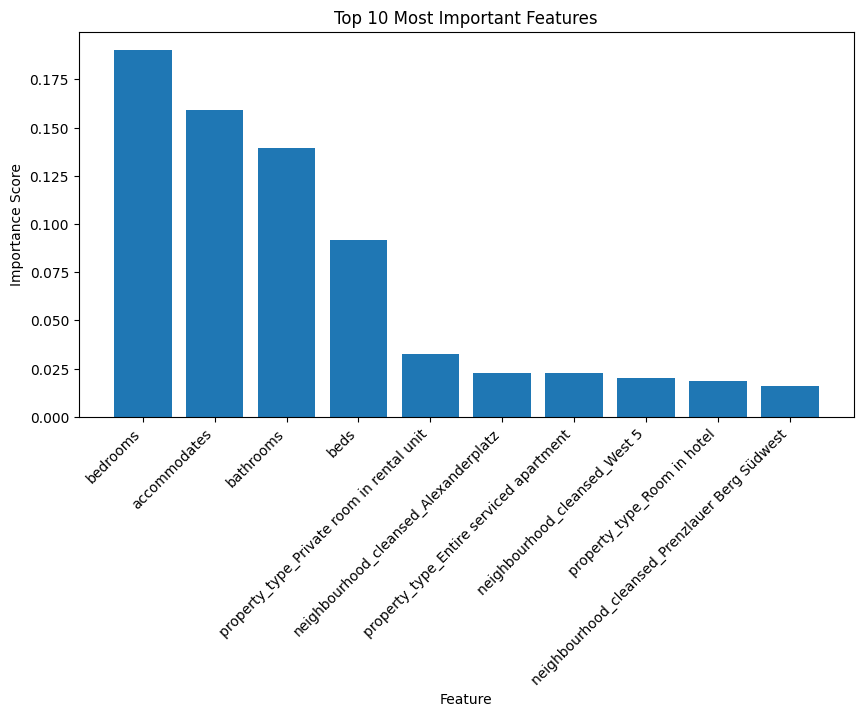

In [82]:
plt.figure(figsize=(10,5))

plt.bar(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Feature")
plt.ylabel("Importance Score")

plt.xticks(rotation=45, ha="right")

plt.show()

In [83]:
top_features["feature"] = top_features["feature"].replace({
    
"property_type_Private room in rental unit": "Private room",
"property_type_Room in hotel": "Hotel room",
"property_type_Entire serviced apartment": "Serviced apt",

"neighbourhood_cleansed_Alexanderplatz": "Alexanderplatz",
"neighbourhood_cleansed_Prenzlauer Berg Südwest": "Prenzlauer Berg SW",
"neighbourhood_cleansed_West 5": "West 5"

})

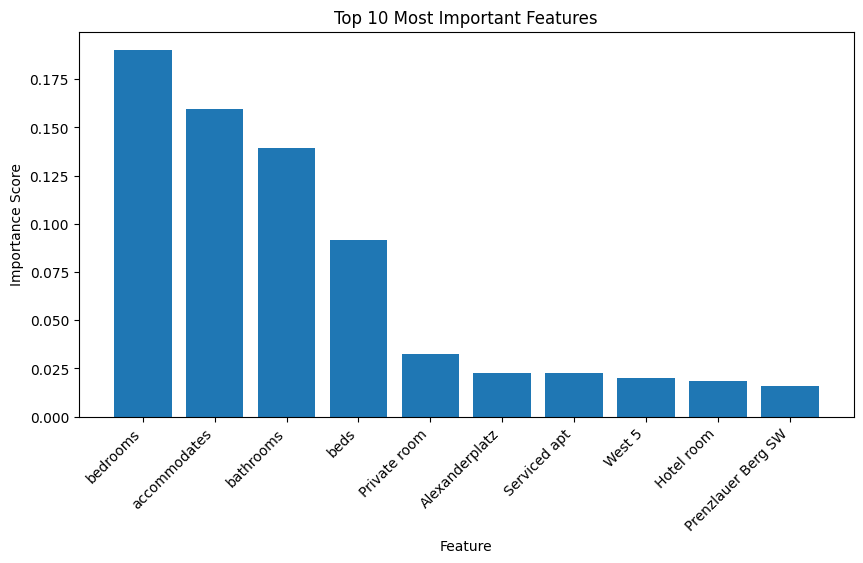

In [84]:
plt.figure(figsize=(10,5))

plt.bar(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Feature")
plt.ylabel("Importance Score")

plt.xticks(rotation=45, ha="right")

plt.show()